# Ajuste de gaussianas en picos dQdV

In [1]:
from pathlib import Path
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.signal import savgol_filter
import func_deriv as func_deriv
import func_plots as func_plots
from scipy.optimize import curve_fit
from scipy.signal import find_peaks


In [2]:
# %% ------- Cargar ciclos ------------------------------------------------------------
input_folder = Path('/home/mariajose/proc-icdv/tmp')
nombre_archivo = "NMC-20"
output_folder = Path('/home/mariajose/proc-icdv/output')
output_folder.mkdir(parents=True, exist_ok=True)  # Create output directory if it doesn't exist

with open(input_folder / f'{nombre_archivo}.json') as f_json:
    raw_dict = json.load(f_json)

dict_ciclos_sep = {
    int(ciclo): {
        etapa: pd.DataFrame(data) for etapa, data in etapas.items()
    }
    for ciclo, etapas in raw_dict.items()
}

indices_ciclos = list(dict_ciclos_sep.keys())

In [3]:
# %% ------- Elegir ciclos ------------------------------------------------------------

# Elijo en todo el rango, equiespaciados
N_ciclos = 10  # Número de ciclos a tomar, si no se especifica, toma todos los del archivo
indices_ciclos_ = indices_ciclos[:-1] # Quito el último
indices_ciclos_array = np.array(indices_ciclos_)
ciclos_disponibles = sorted(dict_ciclos_sep.keys())
ciclos_seleccionados = indices_ciclos_array[np.linspace(0, len(indices_ciclos_array)-1, N_ciclos, dtype=int)]
#print("Ciclos seleccionados:", ciclos_seleccionados)
#print(f"son {len(ciclos_seleccionados)} ciclos")

# Elecciones manuales
#ciclos_reducidos = [3, 21, 78, 153, 228, 303, 378, 453, 528, 603, 678, 753, 828]
#ciclos_seleccionados = [2, 99, 192, 300, 414, 504, 600, 702, 801, 897]
ciclos_seleccionados = [2, 21, 99, 198, 297, 396, 498, 597, 696, 795, 897]
ciclos_seleccionados = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]


excluir = {30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247} # ciclos feos
ciclos_seleccionados = [c for c in ciclos_disponibles if 21 <= c <= 300 and c not in excluir]

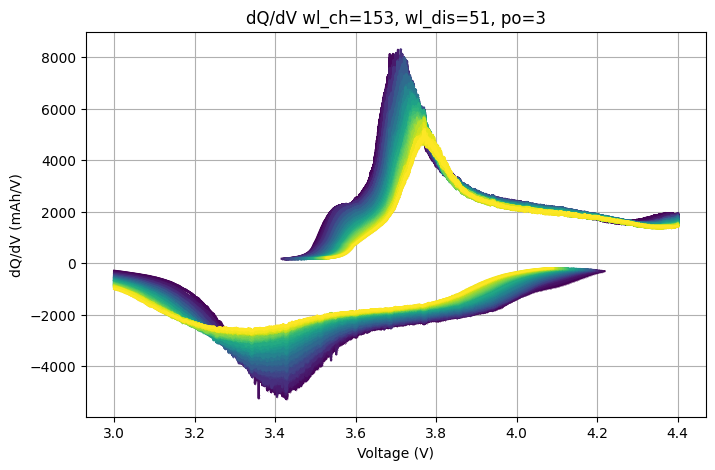

"\ndiccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},\n        99: {'Ch': df_ch_99, 'Dis': df_dis_99},\n        ...\n        }\n"

In [4]:
# %% ------- Trunco datos y calculo derivada ------------------------------------------------------------

# charge (wl = 153, truncar los n=30 puntos iniciales)
# discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)

diccio = func_deriv.truncar_señal(ciclos_seleccionados, dict_ciclos_sep)
diccio =  func_deriv.plot_dqdv(ciclos_seleccionados, diccio)

'''
diccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},
        99: {'Ch': df_ch_99, 'Dis': df_dis_99},
        ...
        }
'''
# Exportar a csv para trabajar en Origin
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)

In [5]:
# %% ------- Defino funciones ajuste ------------------------------------------------------------

def multi_gauss(x, *params):
    """
    params: [a1, mu1, sigma1, a2, mu2, sigma2, ..., an, mun, sigman]
    """
    y = np.zeros_like(x)
    for i in range(0, len(params), 3):
        a, mu, sigma = params[i:i+3]
        y += a * np.exp(-(x-mu)**2 / (2*sigma**2))
    return y


def gauss(x, a, mu, sigma):
    return a * np.exp(-(x-mu)**2 / (2*sigma**2))

In [6]:
# %% ------- Parámetros iniciales ------------------------------------------------------------

p_ini = [
    800, 3.55, 0.002,   # pico 1
    #1500, 3.61, 0.004,  # pico 2 (nuevo intermedio)
    3400, 3.69, 0.002,  # pico 3
    2900, 3.74, 0.013,  # pico 4
    1100, 4.0, 0.02,   # pico 5 (nuevo intermedio)
    2200, 4.39, 0.1    # pico 6
]

n_peaks = len(p_ini) // 3

# lower bounds (a > 0, sigma > 0, mu libre)
lb = []
ub = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lb += [0, mu0-0.05, 1e-6]      # amplitud >=0, mu +- tolerancia, sigma > 0
    ub += [np.inf, mu0+0.05, np.inf]

bounds = (lb, ub)

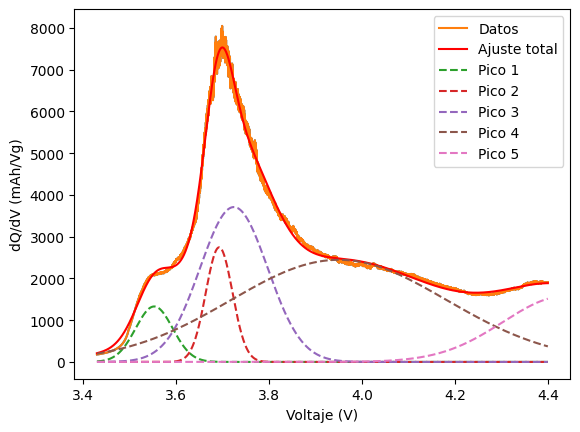

In [7]:
# %% ------- Pruebo con el primer ciclo ------------------------------------------------------------

df_ch = diccio[21]['Ch']
df_dis = diccio[21]['Dis']

dqdv_ch_calc = df_ch['dqdv_ch_calc']
V = df_ch['V_ch_savgol'] 

plt.plot(V, dqdv_ch_calc)

# Ajuste
popt, pcov = curve_fit(multi_gauss, V, dqdv_ch_calc, p0=p_ini, bounds=bounds)

# Curva total ajustada
y_fit = multi_gauss(V, *popt)
plt.plot(V, dqdv_ch_calc, label="Datos")
plt.plot(V, y_fit, 'r-', label="Ajuste total")

# Dibujar cada gaussiana individual
for i in range(0, len(popt), 3):
    a, mu, sigma = popt[i:i+3]
    plt.plot(V, gauss(V, a, mu, sigma), '--', label=f"Pico {i//3 + 1}")

plt.legend()
plt.xlabel("Voltaje (V)")
plt.ylabel("dQ/dV (mAh/Vg)")
plt.savefig(f'./output/ajuste_picos.png', dpi=300)
plt.show()

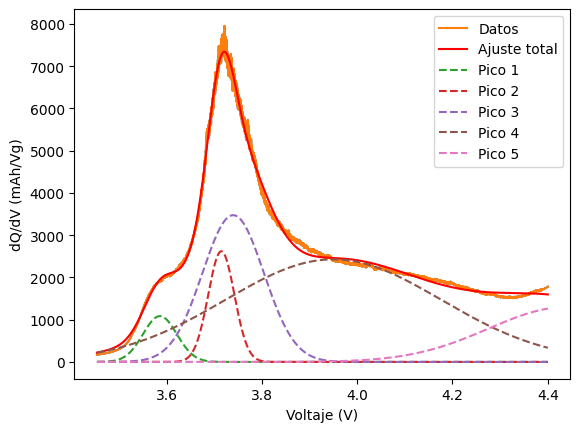

In [8]:
# %% ------- Pruebo con el 2do ciclo ------------------------------------------------------------

df_ch = diccio[99]['Ch']
df_dis = diccio[99]['Dis']

dqdv_ch_calc = df_ch['dqdv_ch_calc']
V = df_ch['V_ch_savgol'] 

plt.plot(V, dqdv_ch_calc)

# Ajuste
popt, pcov = curve_fit(multi_gauss, V, dqdv_ch_calc, p0=popt, bounds=bounds)

# Curva total ajustada
y_fit = multi_gauss(V, *popt)
plt.plot(V, dqdv_ch_calc, label="Datos")
plt.plot(V, y_fit, 'r-', label="Ajuste total")

# Dibujar cada gaussiana individual
for i in range(0, len(popt), 3):
    a, mu, sigma = popt[i:i+3]
    plt.plot(V, gauss(V, a, mu, sigma), '--', label=f"Pico {i//3 + 1}")

plt.legend()
plt.xlabel("Voltaje (V)")
plt.ylabel("dQ/dV (mAh/Vg)")
plt.savefig(f'./output/ajuste_picos.png', dpi=300)
plt.show()

### Loop para muchos ciclos

In [9]:
# %% ------- Parámetros iniciales ------------------------------------------------------------

p_ini = [
    800, 3.55, 0.002,   # pico 1
    3400, 3.69, 0.002,  # pico 2
    2900, 3.74, 0.013,  # pico 3
    1100, 4.0, 0.02,   # pico 4
    2200, 4.39, 0.1    # pico 5
]

n_peaks = len(p_ini) // 3

# lower bounds (a > 0, sigma > 0, mu libre)
lb = []
ub = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lb += [0, mu0-0.05, 1e-6]      # amplitud >=0, mu +- tolerancia, sigma > 0
    ub += [np.inf, mu0+0.05, np.inf]

bounds_ini = (lb, ub)

Ajustando ciclo 21...
Ajustando ciclo 24...
Ajustando ciclo 27...
Ajustando ciclo 33...
Ajustando ciclo 36...
Ajustando ciclo 39...
Ajustando ciclo 42...
Ajustando ciclo 45...
Ajustando ciclo 48...
Ajustando ciclo 51...
Ajustando ciclo 54...
Ajustando ciclo 57...
Ajustando ciclo 60...
Ajustando ciclo 63...
Ajustando ciclo 66...
Ajustando ciclo 69...
Ajustando ciclo 72...
Ajustando ciclo 75...
Ajustando ciclo 78...
Ajustando ciclo 81...
Ajustando ciclo 84...
Ajustando ciclo 87...
Ajustando ciclo 90...
Ajustando ciclo 93...
Ajustando ciclo 96...
Ajustando ciclo 99...
Ajustando ciclo 102...
Ajustando ciclo 105...
Ajustando ciclo 108...
Ajustando ciclo 111...
Ajustando ciclo 114...
Ajustando ciclo 117...
Ajustando ciclo 120...
Ajustando ciclo 123...
Ajustando ciclo 126...
Ajustando ciclo 129...
Ajustando ciclo 132...
Ajustando ciclo 135...
Ajustando ciclo 138...
Ajustando ciclo 141...
Ajustando ciclo 144...
Ajustando ciclo 147...
Ajustando ciclo 150...
Ajustando ciclo 153...
Ajustando cicl

ValueError: Length of values (94) does not match length of index (90)

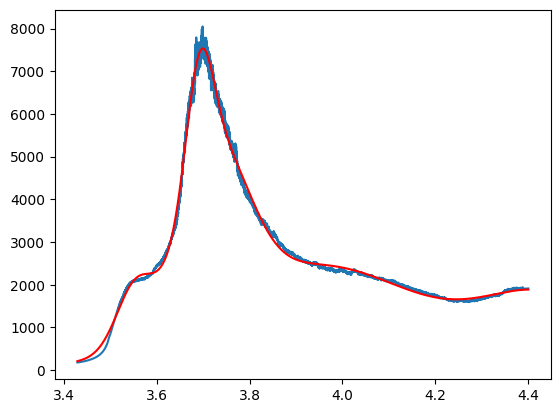

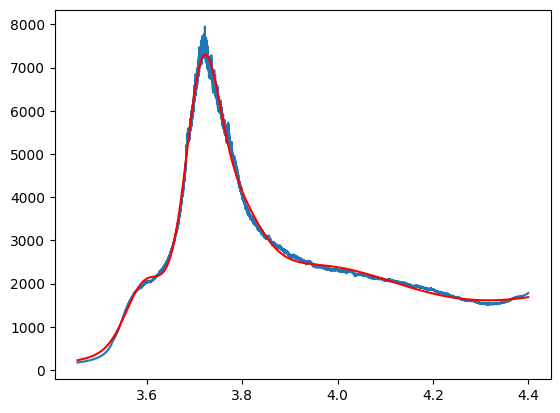

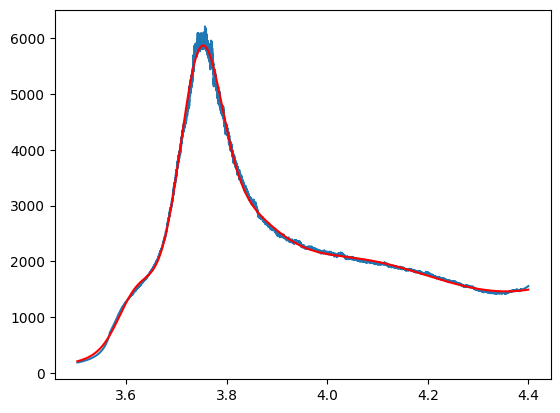

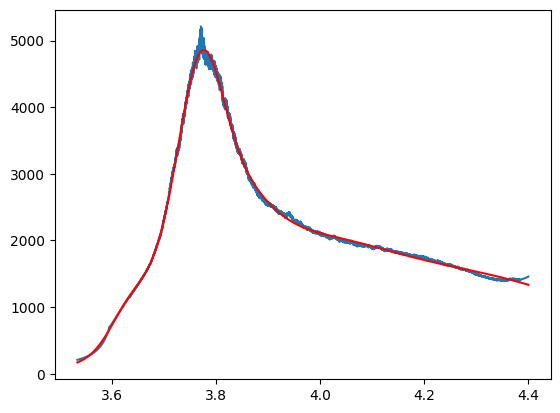

In [10]:
# %% ------- Ajuste encadenado de varios ciclos ------------------------------------------------------------

# ---- Elegir ciclos del loop y nombre del .csv ------------------------------------------------
nombre = 'moreSteps-10bounds'
excluir = {30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247} # ciclos feos
ciclos_seleccionados_ajuste = [c for c in ciclos_disponibles if 21 <= c <= 300 and c not in excluir]
ciclos_grafico = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]
# ----------------------------------------------------------------------------------------------

ciclos = ciclos_seleccionados_ajuste     # los que quieras ajustar
resultados = []                          # lista de parámetros ajustados
covs = []                                # lista de matrices de covarianza
areas = []                               # lista de áreas de cada pico

# inicialización con p_ini
p0_actual = p_ini
bounds_actual = bounds_ini
n_peaks = len(p_ini)//3

# Realizar ajustes
for ciclo in ciclos:
    try:
        df_ch = diccio[ciclo]['Ch']
        V = df_ch['V_ch_savgol']
        dqdv = df_ch['dqdv_ch_calc']
        
        # Ajuste
        print(f'Ajustando ciclo {ciclo}...')
        popt, pcov = curve_fit(multi_gauss, V, dqdv, p0=p0_actual, bounds=bounds_actual,
                               maxfev=20000   # por defecto suele ser 800
                                )
    
        # Guardar resultados
        resultados.append(popt)
        covs.append(pcov)
        
        # Calcular áreas de cada gaussiana
        areas_picos = []
        for i in range(0, len(popt), 3):
            a, mu, sigma = popt[i:i+3]
            area = a * sigma * np.sqrt(2*np.pi)
            areas_picos.append(area)
        areas.append(areas_picos)
    
        # Actualizar p0 para el siguiente ciclo
        p0_actual = popt

        # --- recalcular bounds para el próximo ciclo ---
        lb = []
        ub = []
        for i in range(n_peaks):
            a0, mu0, sigma0 = popt[3*i:3*i+3]
            lb += [0.9*a0, 0.9*mu0, 0.9*sigma0]
            ub += [1.1*a0, 1.1*mu0, 1.1*sigma0]
        bounds_actual = (lb, ub)

        # Plot
        if ciclo in ciclos_grafico:
            plt.figure()
            y_fit = multi_gauss(V, *popt)
            plt.plot(V, dqdv, label=f"Datos ciclo {ciclo}")
            plt.plot(V, y_fit, 'r-', label="Ajuste total")

            for i in range(0, len(popt), 3):
                a, mu, sigma = popt[i:i+3]
                j = i // 3   # índice de pico: 0,1,2,...
                plt.plot(V, gauss(V, a, mu, sigma), '--', color=colors[j % len(colors)], label=f"Pico {j + 1}")

            plt.legend()
            plt.xlabel("Voltaje (V)")
            plt.ylabel("dQ/dV (mAh/Vg)")
            plt.title(f"Ajuste ciclo {ciclo}")
            plt.savefig(f'./output/ajuste_picos_ciclo{ciclo}_{nombre}.png', dpi=300)
            plt.close()
    
    except Exception as e:
        # si falla, llenar con NaN
        resultados.append([np.nan,np.nan,np.nan] * n_peaks)
        covs.append(np.full((n_peaks*3, n_peaks*3), np.nan))  # matriz covarianza "vacía"
        areas.append([np.nan] * n_peaks)

# %% ------- Crear DataFrame con parámetros y áreas ------------------------------------------------------------
cols = []
cols_area = []

for i in range(n_peaks):
    cols += [f"a{i+1}", f"mu{i+1}", f"sigma{i+1}"]
    cols_area.append(f"area{i+1}")

df_params = pd.DataFrame(resultados, index=ciclos, columns=cols)
df_areas = pd.DataFrame(areas, index=ciclos, columns=cols_area)
df_final = pd.concat([df_params, df_areas], axis=1)

# Guardar a CSV
df_final.to_csv(f"./output/parametros_ajustes_{nombre}.csv")

print(f"Ajustes terminados. Resultados guardados en './output/parametros_ajustes_{nombre}.csv'")

In [ ]:
#df_final = pd.read_csv("./output/parametros_ajustes.csv", index_col=0)
#df_final = pd.read_csv("./output/parametros_ajustes_10bound.csv", index_col=0)
df_final = pd.read_csv("./output/parametros_ajustes_moreSteps-10bounds.csv", index_col=0)

df_final.head()

,a1,mu1,sigma1,a2,mu2,sigma2,a3,mu3,sigma3,a4,mu4,sigma4,a5,mu5,sigma5,area1,area2,area3,area4,area5
21,1328.772384,3.552511,0.039804,2745.222119,3.692398,0.028686,3710.381861,3.724055,0.072794,2446.467201,3.950000,0.231906,1581.087179,4.440000,0.136387,132.577514,197.393575,677.028124,1422.136404,540.529622
24,1260.797361,3.554093,0.036843,2470.699907,3.689954,0.031554,3513.375738,3.721991,0.070283,2486.639298,3.923763,0.235759,1650.383261,4.445918,0.150026,116.437764,195.419639,618.965194,1469.501987,620.642022
27,1181.139292,3.554553,0.033508,2717.769897,3.692979,0.028399,3554.041741,3.716839,0.066752,2567.205042,3.908130,0.226379,1632.144591,4.440572,0.165029,99.206298,193.465442,594.671342,1456.752546,675.161521
33,1246.387139,3.558916,0.036818,2644.345679,3.695428,0.027912,3491.473154,3.723584,0.068616,2550.849436,3.917150,0.230028,1795.359050,4.496263,0.181531,115.027394,185.013675,600.512658,1470.807270,816.945440
36,1371.025853,3.559283,0.037189,2773.027358,3.695054,0.030704,3467.074718,3.727035,0.069052,2461.366969,3.930417,0.234835,1974.894956,4.541959,0.199685,127.805377,213.418686,600.107977,1448.871015,988.503982


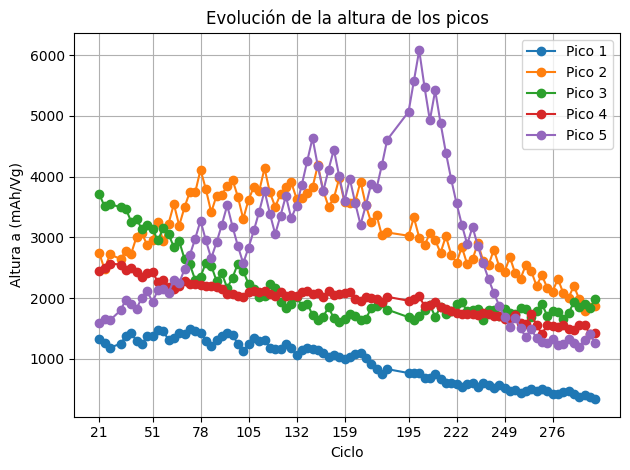

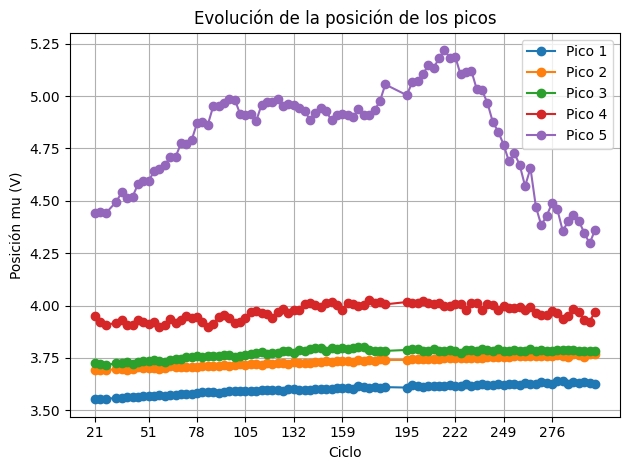

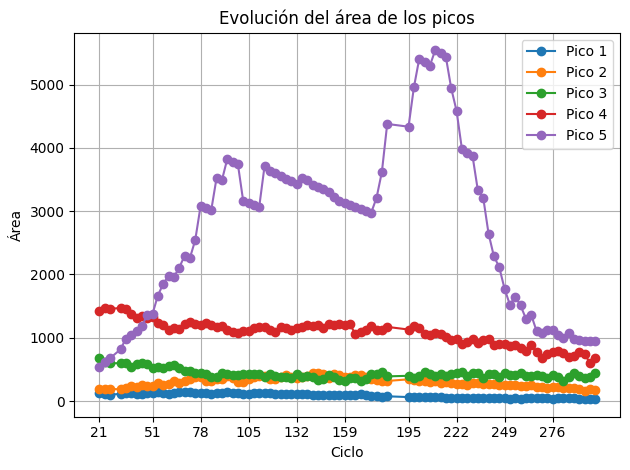

In [ ]:
# %% ------------ Graficar evolución de los parámetros con los ciclos  ----------------------------------------

# ------ Elegir cuál y de qué loop ---------------
ciclo = 279
#df_final = pd.read_csv("./output/parametros_ajustes.csv", index_col=0)
df_final = pd.read_csv("./output/parametros_ajustes_moreSteps-10bounds.csv", index_col=0)
nombre = 'moreSteps-10bounds' # etiqueta gráfico
# ------------------------------------------------

n_peaks = len(p_ini)//3
colors = cm.tab10.colors  # paleta con 10 colores distintos

# Evolución de la altura (a)
plt.figure()
for i in range(n_peaks): # 0,1,2
    plt.plot(df_final.index, df_final[f"a{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
plt.xlabel("Ciclo")
plt.ylabel("Altura a (mAh/Vg)")
plt.xticks(df_final.index[::9])
plt.title("Evolución de la altura de los picos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"./output/evolucion_altura_picos_{nombre}.png", dpi=300)
plt.show()

# Evolución de la posición (mu)
plt.figure()
for i in range(n_peaks):
    plt.plot(df_final.index, df_final[f"mu{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
plt.xlabel("Ciclo")
plt.ylabel("Posición mu (V)")
plt.xticks(df_final.index[::9])
plt.title("Evolución de la posición de los picos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"./output/evolucion_posicion_picos_{nombre}.png", dpi=300)
plt.show()

# Evolución del área
plt.figure()
for i in range(n_peaks):
    plt.plot(df_final.index, df_final[f"area{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
plt.xlabel("Ciclo")
plt.ylabel("Área")
plt.xticks(df_final.index[::9])
plt.title("Evolución del área de los picos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"./output/evolucion_area_picos_{nombre}.png", dpi=300)
plt.show()

#### Grafico ajuste de un ciclo particular

[3.31210154e+02 3.62697676e+00 3.43010547e-02 1.87485155e+03
 3.76668494e+00 3.76581868e-02 1.98066448e+03 3.78191350e+00
 8.97829135e-02 1.42329405e+03 3.97098059e+00 1.89188882e-01
 1.26252097e+03 4.36098560e+00 2.97967533e-01 2.84774469e+01
 1.76976755e+02 4.45753274e+02 6.74963328e+02 9.42969141e+02]
5
[3.31210154e+02 3.62697676e+00 3.43010547e-02 1.87485155e+03
 3.76668494e+00 3.76581868e-02 1.98066448e+03 3.78191350e+00
 8.97829135e-02 1.42329405e+03 3.97098059e+00 1.89188882e-01
 1.26252097e+03 4.36098560e+00 2.97967533e-01]


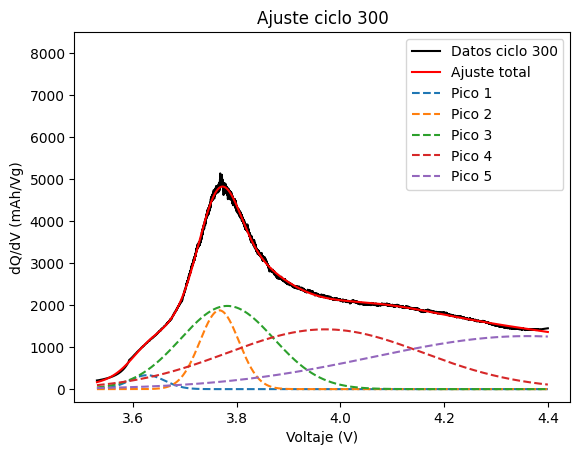

In [18]:
# %% ------------ Graficar ajuste de un ciclo usando lista de parámetros ----------------------------------------

# ------ Elegir cuál y de qué loop ---------------
ciclo = 300
#df_final = pd.read_csv("./output/parametros_ajustes.csv", index_col=0)
df_final = pd.read_csv("./output/parametros_ajustes_moreSteps-10bounds.csv", index_col=0)
nombre = 'moreSteps-10bounds' # etiqueta gráfico
# ------------------------------------------------

df_ch = diccio[ciclo]['Ch']
dqdv = df_ch['dqdv_ch_calc']
V = df_ch['V_ch_savgol']

parametros = df_final.loc[ciclo].values
popt = parametros[:n_peaks*3]

print(parametros)
print(n_peaks)
print(popt)

#colors_ciclos = cm.viridis(np.linspace(0, 1, len(indices_ciclos)))
colors_peaks = cm.tab10.colors
#colors_peaks = cm.cool(np.linspace(0, 1, n_peaks))

plt.figure()

y_fit = multi_gauss(V, *popt)
#plt.plot(V, dqdv, color=colors_ciclos[ciclo], label=f"Datos ciclo {ciclo}")
plt.plot(V, dqdv, color='black', label=f"Datos ciclo {ciclo}")
plt.plot(V, y_fit, 'r-', label="Ajuste total")

for i in range(0, len(popt), 3):
    a, mu, sigma = popt[i:i+3]
    j = i // 3   # índice de pico: 0,1,2,...
    plt.plot(V, gauss(V, a, mu, sigma), '--', color=colors_peaks[j % len(colors_peaks)], label=f"Pico {j + 1}")

plt.legend()
plt.xlabel("Voltaje (V)")
plt.ylabel("dQ/dV (mAh/Vg)")
plt.title(f"Ajuste ciclo {ciclo}")

plt.ylim(-300,8500)



plt.savefig(f'./output/ajuste_picos_ciclo{ciclo}_{nombre}.png', dpi=300)
#plt.close()
plt.show()

#### Pruebo ajuste de un ciclo particular

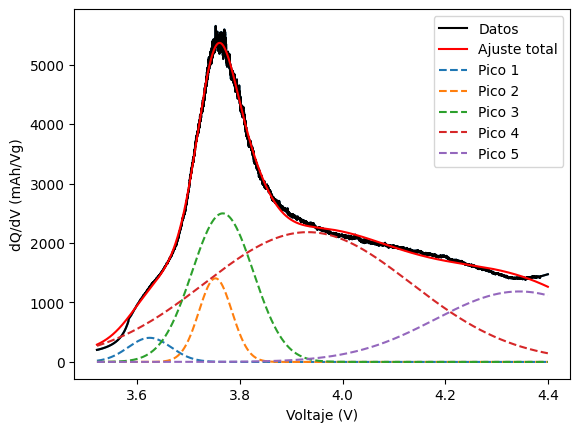

In [16]:
# %% ------- Pruebo ajustar un ciclo particular ------------------------------------------------------------

# ------ Elegir cuál y de qué loop tomar los parametros anteriores ---------------
ciclo = 252
df_final = pd.read_csv("./output/parametros_ajustes.csv", index_col=0)
nombre = '' # etiqueta gráfico
# --------------------------------------------------------------------------------


df_ch = diccio[ciclo]['Ch']
df_dis = diccio[ciclo]['Dis']
dqdv_ch_calc = df_ch['dqdv_ch_calc']
V = df_ch['V_ch_savgol']

plt.plot(V, dqdv_ch_calc)
colors_peaks = cm.tab10.colors

# Tomo como parametros iniciales y bounds el ajuste del ciclo anterior
loc = df_final.index.get_loc(ciclo)   # posición del ciclo dentro del DataFrame
ciclo_anterior = df_final.index[loc-1]
parametros = df_final.loc[ciclo_anterior].values
popt = parametros[:n_peaks*3]   # me quedo con a, mu, sigma
p0_actual = popt

lb = []
ub = []
for i in range(n_peaks):
    a0, mu0, sigma0 = popt[3*i:3*i+3]
    lb += [0.9*a0, 0.9*mu0, 0.9*sigma0]
    ub += [1.1*a0, 1.1*mu0, 1.1*sigma0]
bounds_actual = (lb, ub)


# Ajuste
popt, pcov = curve_fit(multi_gauss, V, dqdv_ch_calc, p0=p0_actual, bounds=bounds_actual, maxfev=20000   # por defecto suele ser 800
)

# Curva total ajustada
y_fit = multi_gauss(V, *popt)
plt.plot(V, dqdv_ch_calc, label="Datos", color='black')
plt.plot(V, y_fit, 'r-', label="Ajuste total")

# Dibujar cada gaussiana individual
for i in range(0, len(popt), 3):
    a, mu, sigma = popt[i:i+3]
    plt.plot(V, gauss(V, a, mu, sigma),'--', color=colors_peaks[i // 3 % len(colors_peaks)],  label=f"Pico {i//3 + 1}")

plt.legend()
plt.xlabel("Voltaje (V)")
plt.ylabel("dQ/dV (mAh/Vg)")
plt.savefig(f'./output/ajuste_picos.png', dpi=300)
plt.show()